<a href="https://colab.research.google.com/github/artuurog/Machine_Learning_LAB/blob/main/Lab_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic VLM usage example

Import the necessary packages

In [1]:
import os
import base64
from openai import OpenAI
from PIL import Image
import matplotlib.pyplot as plt

The image can be either taken from the internet (copy and paste its URL) or it can be taken from the local storage (as shown in the example).

The Statue of Liberty stands proudly on a small island in New York Harbor, with the iconic Manhattan skyline and the Empire State Building visible in the background.


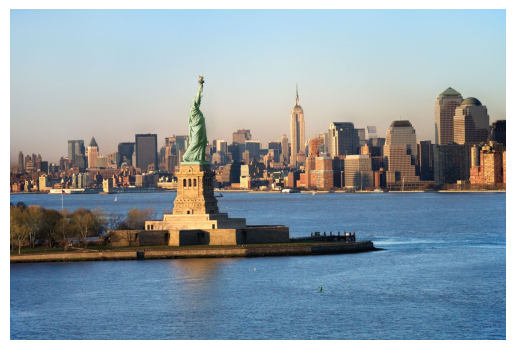

In [ ]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

os.environ['HF_TOKEN'] = 'your_api_key_goes_here'

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

# Import image
!wget -q https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg -O sample.png

base64_image = encode_image("sample.png")

completion = client.chat.completions.create(
    model="allenai/Molmo2-8B",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Describe this image in one sentence."
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
)

print(completion.choices[0].message.content)

# Show image
image = Image.open("sample.png")
plt.imshow(image)
plt.axis("off")
plt.show()

# MuJoCo example

Install packages

In [2]:
!pip install -q mujoco
!pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.0 MB/s eta 0:00:00


Load the model and visualize it

Cloning into 'GoFa_MuJoCo_sim'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 147 (delta 51), reused 108 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 3.29 MiB | 20.94 MiB/s, done.
Resolving deltas: 100% (51/51), done.


""

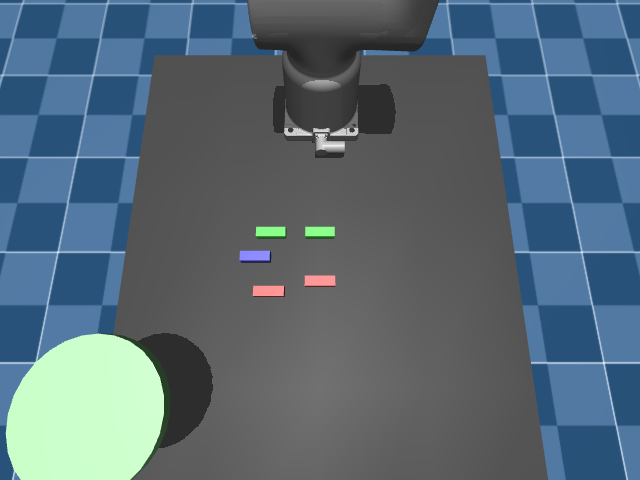

In [4]:
import os
# Set render to EGL
os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import mujoco.viewer
import mediapy as media

# Clone the model repository
!rm -r GoFa_MuJoCo_sim/
!git clone https://github.com/artuurog/GoFa_MuJoCo_sim.git

xml_path = "GoFa_MuJoCo_sim/gofa/pick_place_scene.xml"

# Load model
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

# Render scene
with mujoco.Renderer(model, 480, 640) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data, camera="external_camera")
  pixels = renderer.render()
  media.show_image(pixels)

## Moving the robot

First we implement an inverse kinematics (IK) solver using the Lavenberg-Marquardt optimization method

In [8]:
import numpy as np
import mediapy as media

#Levenberg-Marquardt method
class LevenbergMarquardtIK:
    """
    Levenberg-Marquardt Inverse Kinematics solver.

    Supports two modes, selected by the 'orientation_weight' parameter:
      • position-only  : orientation_weight = 0  (backward compatible)
      • position + orientation : orientation_weight > 0  (default 1.0)

    Goal for position-only  : np.array([x, y, z])
    Goal for full pose      : (np.array([x, y, z]), R_goal_3x3)
                               where R_goal_3x3 is a 3×3 rotation matrix.
                               Helper rotation_matrix_from_euler() is provided.
    """

    def __init__(self, model, data,
                 step_size=0.5,
                 tol=0.001,
                 alpha=0.5,
                 jacp=None,
                 jacr=None,
                 damping=0.01,
                 orientation_weight=1.0,
                 max_iter=1000):

        self.model = model
        self.data  = data
        self.step_size         = step_size
        self.tol               = tol
        self.alpha             = alpha
        self.damping           = damping
        self.orientation_weight = orientation_weight
        self.max_iter          = max_iter

        # Jacobian buffers – allocate internally if not provided
        nv = model.nv
        self.jacp = jacp if jacp is not None else np.zeros((3, nv))
        self.jacr = jacr if jacr is not None else np.zeros((3, nv))

    # ------------------------------------------------------------------
    def check_joint_limits(self, q):
        """Clamp joint angles to their model limits."""
        for i in range(len(q)):
            q[i] = max(self.model.jnt_range[i][0],
                       min(q[i], self.model.jnt_range[i][1]))

    # ------------------------------------------------------------------
    def _get_site_rotation(self, site_id):
        """Return the 3×3 rotation matrix of a site from xmat (row-major 9-vec)."""
        return self.data.site(site_id).xmat.reshape(3, 3).copy()

    # ------------------------------------------------------------------
    def rotation_matrix_from_euler(self, roll, pitch, yaw, seq="zyx"):
        """

        Parameters
        ----------
        roll, pitch, yaw: euler angles in rad
        seq : The default is "zyx".

        Returns
        -------
        Rotation matrix

        """

        quat = np.zeros(4)
        euler = np.array([roll, pitch, yaw])

        mujoco.mju_euler2Quat(quat, euler, seq)

        mat = np.zeros(9)
        mujoco.mju_quat2Mat(mat, quat)

        return mat.reshape(3, 3)


    # ------------------------------------------------------------------
    def rotation_error(self, R_current, R_goal):
        """
        Compute the orientation error as an axis-angle vector (3D).

        Uses the formula:  e_R = 0.5 * (R_goal - R_current)^skew_extract
        i.e., the 'vee' of the skew-symmetric part of  R_goal @ R_current.T

        Returns a 3-vector in the body frame that drives R_current -> R_goal.
        """
        R_err = R_goal @ R_current.T          # relative rotation matrix
        # Extract the axis-angle vector from the skew-symmetric part
        # rot_vec = [R32-R23, R13-R31, R21-R12] / 2
        e_R = 0.5 * np.array([
            R_err[2, 1] - R_err[1, 2],
            R_err[0, 2] - R_err[2, 0],
            R_err[1, 0] - R_err[0, 1]
        ])
        return e_R


    # ------------------------------------------------------------------
    def calculate(self, goal, init_q, body_id):
        """
        Run the IK solver.

        Parameters
        ----------
        goal     : array-like [x,y,z]          (position-only mode)
                   or tuple  ([x,y,z], R_3x3)  (full-pose mode)
        init_q   : array-like, initial joint configuration
        body_id  : int, site id (use model.site('ee_site').id)

        Returns
        -------
        converged : bool  – True if the solver reached tolerance
        n_iter    : int   – number of iterations performed
        """

        # ---- Parse goal --------------------------------------------------
        if isinstance(goal, (tuple, list)) and len(goal) == 2 \
                and isinstance(goal[1], np.ndarray) and goal[1].shape == (3, 3):
            pos_goal = np.asarray(goal[0], dtype=float)
            R_goal   = goal[1]
            use_orientation = (self.orientation_weight > 0.0)
        else:
            pos_goal = np.asarray(goal, dtype=float)
            R_goal   = None
            use_orientation = False

        # ---- Initialise --------------------------------------------------
        self.data.qpos[:] = init_q
        mujoco.mj_forward(self.model, self.data)

        # ---- Build the combined error vector -----------------------------
        def compute_error():
            pos_err = pos_goal - self.data.site(body_id).xpos
            if use_orientation:
                R_cur   = self._get_site_rotation(body_id)
                rot_err = self.orientation_weight * self.rotation_error(R_cur, R_goal)
                return np.concatenate([pos_err, rot_err])   # shape (6,)
            return pos_err                                   # shape (3,)

        error = compute_error()

        converged = False
        n_iter    = 0

        while np.linalg.norm(error) >= self.tol:
            if n_iter >= self.max_iter:
                print(f"[IK] WARNING: max iterations ({self.max_iter}) reached. "
                      f"Residual error = {np.linalg.norm(error):.6f}")
                break

            # ---- Compute Jacobians ---------------------------------------
            mujoco.mj_jacSite(self.model, self.data,
                               self.jacp, self.jacr, body_id)

            # ---- Build the task-space Jacobian J -------------------------
            if use_orientation:
                # Stack translational (3×nv) and rotational (3×nv) parts → (6×nv)
                J = np.vstack([self.jacp,
                               self.orientation_weight * self.jacr])
            else:
                J = self.jacp   # (3×nv)

            # ---- Levenberg-Marquardt pseudo-inverse ----------------------
            n = J.shape[1]
            I = np.eye(n)
            A = J.T @ J + self.damping * I   # (nv×nv)  – always well-conditioned

            if np.isclose(np.linalg.det(A), 0):
                j_inv = np.linalg.pinv(A) @ J.T
            else:
                j_inv = np.linalg.solve(A, J.T)   # more stable than explicit inv

            delta_q = j_inv @ error

            # ---- Update joint angles -------------------------------------
            self.data.qpos[:] += self.step_size * delta_q
            self.check_joint_limits(self.data.qpos)

            # ---- Forward kinematics & new error --------------------------
            mujoco.mj_forward(self.model, self.data)
            error = compute_error()

            n_iter += 1

        else:
            converged = True

        return converged, n_iter

Example usage of the IK solver

Results
Goal point => [0.5, 0.1, 0.2]
Levenberg-Marquardt result => [0.49973185 0.0998412  0.20052586] 



Initial,Levenberg-Marquardt result

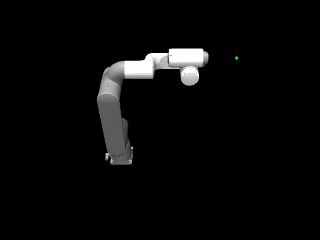
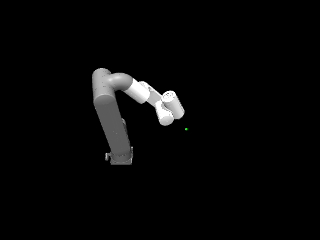

In [9]:
xml_path = "GoFa_MuJoCo_sim/gofa/robot_no_gripper.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

# Add external camera
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2

#Reset state and time
mujoco.mj_resetData(model, data)

#Init variables.
body_id = model.site('ee_site').id
jacp = np.zeros((3, model.nv)) #translation jacobian
jacr = np.zeros((3, model.nv)) #rotational jacobian
# goal = [0.5, 0.10, 0.2]
# ------------------------------------------------------------------
# Build a reference pose from a known joint configuration
# ------------------------------------------------------------------
data.qpos = [-3*np.pi/2, -np.pi/4, np.pi/3, 0, np.pi/2, 0] # target joint angles
qpos0 = data.qpos.copy()
mujoco.mj_forward(model, data)

site_id = model.site('ee_site').id

target_pos = data.site('ee_site').xpos.copy()
target_rot = data.site(site_id).xmat.reshape(3, 3).copy()


print("Target position  =>", target_pos)
print("Target rotation  =>\n", target_rot)

# Parameters for the IK solver
step_size = 0.5
tol = 0.001
alpha = 0.5
init_q = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
damping = 0.01

ik = LevenbergMarquardtIK(model, data, step_size, tol, alpha, jacp, jacr, damping)

# Compute inverse kinematics
mujoco.mj_resetDataKeyframe(model, data, 1) #reset qpos to initial value
ik.calculate(goal, init_q, body_id) #calculate the qpos
result = data.qpos.copy()

#Plot results
print("Results")
data.qpos = init_q
mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
target_plot = renderer.render()

data.qpos = result
mujoco.mj_forward(model, data)
result_point = data.site('ee_site').xpos
renderer.update_scene(data, camera)
result_plot = renderer.render()

print("Goal point =>", goal)
print("Levenberg-Marquardt result =>", result_point, "\n")

images = {
    'Initial': target_plot,
    'Levenberg-Marquardt result': result_plot,
}

media.show_images(images)

Target position  => [0.002      0.17781816 0.28640669]
Target rotation  =>
 [[ 1.38777878e-16 -1.00000000e+00 -1.66533454e-16]
 [-2.58819045e-01 -2.22044605e-16  9.65925826e-01]
 [-9.65925826e-01 -5.55111512e-17 -2.58819045e-01]]

--- Test 1: position only ---
  Converged: True  |  Iterations: 28
  EE position  => [0.00274849 0.17762661 0.2864911 ]

--- Test 2: position + orientation ---
  Converged: True  |  Iterations: 34
  EE position  => [0.00246143 0.1777027  0.2864181 ]
  EE rotation  =>
[[ 1.76641618e-04 -9.99999971e-01  1.63855854e-04]
 [-2.58216699e-01  1.12687201e-04  9.66087017e-01]
 [-9.66087007e-01 -2.12961492e-04 -2.58216671e-01]]
  Orientation error norm => 0.000668
Results
Goal point => [0.002      0.17781816 0.28640669]
Levenberg-Marquardt result => [0.00246143 0.1777027  0.2864181 ] 



Initial,Levenberg-Marquardt result

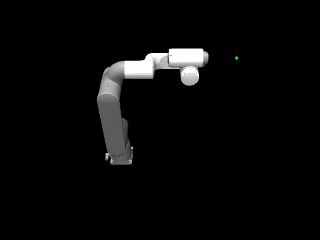
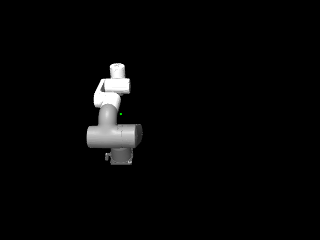

In [14]:
xml_path = "GoFa_MuJoCo_sim/gofa/robot_no_gripper.xml"
model    = mujoco.MjModel.from_xml_path(xml_path)
data     = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2

# ------------------------------------------------------------------
# Build a reference pose from a known joint configuration
# ------------------------------------------------------------------
data.qpos = [-3*np.pi/2, -np.pi/4, np.pi/3, 0, np.pi/2, 0] # target joint angles
qpos0 = data.qpos.copy()
mujoco.mj_forward(model, data)

site_id = model.site('ee_site').id

target_pos = data.site('ee_site').xpos.copy()
target_rot = data.site(site_id).xmat.reshape(3, 3).copy()


print("Target position  =>", target_pos)
print("Target rotation  =>\n", target_rot)

# ------------------------------------------------------------------
# Test 1 – position only  (backward-compatible mode)
# ------------------------------------------------------------------
print("\n--- Test 1: position only ---")

init_q = np.zeros(model.nq)
ik = LevenbergMarquardtIK(model, data,
                          step_size=0.25, tol=0.001,
                          damping=0.01, orientation_weight=0.0)

mujoco.mj_resetDataKeyframe(model, data, 1)
converged, n_iter = ik.calculate(target_pos, init_q, site_id)

result_pos_only = data.qpos.copy()
mujoco.mj_forward(model, data)
print(f"  Converged: {converged}  |  Iterations: {n_iter}")
print(f"  EE position  => {data.site('ee_site').xpos}")

# ------------------------------------------------------------------
# Test 2 – position + orientation
# ------------------------------------------------------------------
print("\n--- Test 2: position + orientation ---")

# Define a goal orientation via Euler angles (roll, pitch, yaw in radians).
# Here we use the same rotation as the reference pose to verify convergence.
R_goal = target_rot   # replace with rotation_matrix_from_euler(roll, pitch, yaw)

goal_pose = (target_pos, R_goal)

mujoco.mj_resetDataKeyframe(model, data, 1)

converged, n_iter = LevenbergMarquardtIK(model, data,
                    step_size=0.25, tol=0.001,
                    damping=0.01, orientation_weight=1).calculate(goal_pose, init_q, site_id)

result_full_pose = data.qpos.copy()
mujoco.mj_forward(model, data)
R_result = data.site(site_id).xmat.reshape(3, 3)

print(f"  Converged: {converged}  |  Iterations: {n_iter}")
print(f"  EE position  => {data.site('ee_site').xpos}")
print(f"  EE rotation  =>\n{R_result}")
print(f"  Orientation error norm => "
    f"{np.linalg.norm(ik.rotation_error(R_result, R_goal)):.6f}")


# ------------------------------------------------------------------
# Plot results
# ------------------------------------------------------------------
print("Results")
data.qpos = init_q
mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
initial_plot = renderer.render()

data.qpos = result_full_pose
mujoco.mj_forward(model, data)
result_point = data.site('ee_site').xpos
renderer.update_scene(data, camera)
result_plot = renderer.render()

print("Goal point =>", target_pos)
print("Levenberg-Marquardt result =>", result_point, "\n")

images = {
    'Initial': initial_plot,
    'Levenberg-Marquardt result': result_plot,
}

media.show_images(images)

## Simulate and render video

In [7]:
def check_joint_limits(q):
    """Check if the joints is under or above its limits"""
    for i in range(len(q)):
        q[i] = max(model.jnt_range[i][0], min(q[i], model.jnt_range[i][1]))



xml_path = "GoFa_MuJoCo_sim/gofa/robot_no_gripper.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

#Video Setup
DURATION = 10 #(seconds)
FRAMERATE = 25 #(Hz)
frames = []

#Reset state and time.
mujoco.mj_resetData(model, data)

#Init position.
# pi = np.pi
# data.qpos = [3*pi/2, -pi/2, pi/2, 3*pi/2, 3*pi/2, 0] #ENABLE if you want test circle

#Init parameters
jacp = np.zeros((3, model.nv)) #translation jacobian
jacr = np.zeros((3, model.nv)) #rotational jacobian
step_size = 0.5
tol = 0.01
damping = 0.01

#Get error.
end_effector_id = model.site('ee_site').id #"End-effector we wish to control.
current_pose = data.site(end_effector_id).xpos #Current pose

goal = [0.5, 0.10, 0.2] # goal position

error = np.subtract(goal, current_pose) #Init Error

#Simulate
data.time = 0
print("Saving frames...")
while data.time < DURATION:

  if (np.linalg.norm(error) >= tol):
      #Calculate jacobian
      mujoco.mj_jacSite(model, data, jacp, jacr, body_id)
      #Calculate delta of joint q
      n = jacp.shape[1]
      I = np.identity(n)
      product = jacp.T @ jacp + damping * I

      if np.isclose(np.linalg.det(product), 0):
          j_inv = np.linalg.pinv(product) @ jacp.T
      else:
          j_inv = np.linalg.inv(product) @ jacp.T

      delta_q = j_inv @ error

      #Compute next step
      q = data.qpos.copy()
      q += step_size * delta_q

      #Check limits
      check_joint_limits(data.qpos)

      #Set control signal
      data.ctrl = q
      #Step the simulation.
      mujoco.mj_step(model, data)

      error = np.subtract(goal, data.site(end_effector_id).xpos)

  #Render and save frames.
  if len(frames) < data.time * FRAMERATE:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

  data.time += 1/FRAMERATE
#Display video.
print("Rendering video...")
media.show_video(frames, fps=FRAMERATE)

print(f"Goal position: {goal}")
print(f"Final result: {data.site(end_effector_id).xpos}")

Saving frames...
Rendering video...


This browser does not support the video tag.


Goal position: [0.5, 0.1, 0.2]
Final result: [0.50789272 0.0995891  0.22050187]


## Open and close gripper

Moving to target position 1: [0.5, 0.1, 0.4]
Reached target position: [0.50024909 0.09980473 1.00049962]

Moving to target position 2: [0, 0.5, 0.4]
Reached target position: [7.35526339e-05 4.99409788e-01 1.00002825e+00]

Moving to target position 3: [-0.5, 0.0, 0.4]
Reached target position: [-4.99511269e-01 -1.15486427e-04  9.99625086e-01]

Moving to target position 4: [-0.4, 0, 0.2]
Reached target position: [-3.99281183e-01 -1.08679500e-04  7.99960363e-01]

Displaying steps...


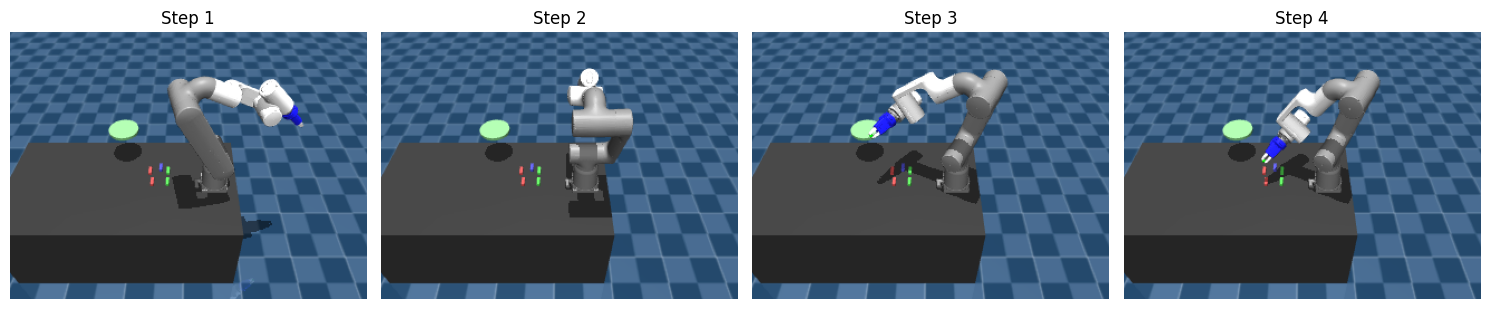

In [ ]:
import matplotlib.pyplot as plt

# Model for IK computation
xml_path_ik = "GoFa_MuJoCo_sim/gofa/robot_no_gripper.xml"
model_ik = mujoco.MjModel.from_xml_path(xml_path_ik)
data_ik = mujoco.MjData(model_ik)

# Model for visualization and gripper control
xml_path = "GoFa_MuJoCo_sim/gofa/scene.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

# Names of the joints in the visualization model
joint_names = ["joint1", "joint2", "joint3", "joint4", "joint5", "joint6"]
dof_ids = np.array([model.joint(name).id for name in joint_names])
actuator_ids = np.array([model.actuator(name + "_act").id for name in joint_names])
dof_ids = np.append(dof_ids, model.joint("joint_finger1").id)
dof_ids = np.append(dof_ids, model.joint("joint_finger2").id)
actuator_ids = np.append(actuator_ids, model.actuator("finger1_act").id)
actuator_ids = np.append(actuator_ids, model.actuator("finger2_act").id)

# Add external camera
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2

# Positions
target_positions = [
    [0.5, 0.1, 0.4],  # First target position
    [0, 0.5, 0.4],
    [-0.5, 0.0, 0.4],
    [-0.4, 0, 0.2]
]

#Reset state and time
mujoco.mj_resetData(model_ik, data_ik)
mujoco.mj_resetData(model, data)

#Init variables.
body_id = model_ik.site('ee_site').id
jacp = np.zeros((3, model_ik.nv)) #translation jacobian
jacr = np.zeros((3, model_ik.nv)) #rotational jacobian

# Parameters for the IK solver
step_size = 0.5
tol = 0.001
damping = 0.01

# init_q = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ik = LevenbergMarquardtIK(model_ik, data_ik, step_size, tol, alpha, jacp, jacr, damping)

captured_images = []

# Open gripper
data.ctrl[model.actuator("finger1_act").id] = -0.006
data.ctrl[model.actuator("finger2_act").id] = 0.006

for i, target_pos in enumerate(target_positions):
    print(f"Moving to target position {i+1}: {target_pos}")

    # Reset data_ik to initial qpos for each new target calculation
    mujoco.mj_resetDataKeyframe(model_ik, data_ik, 1) # Reset to a neutral initial pose
    init_q = data_ik.qpos.copy()

    # Calculate the qpos for the current target
    # The ik_solver's calculate method modifies data.qpos directly
    ik.calculate(target_pos, init_q, body_id)

    # Get the resulting joint configuration
    result_qpos = data_ik.qpos.copy()

    # Set the robot to the calculated qpos for rendering
    data.qpos[[model.joint(name).id for name in joint_names]] = result_qpos
    mujoco.mj_forward(model, data)

    # Render the scene and capture the image
    renderer.update_scene(data, camera)
    pixels = renderer.render()
    captured_images.append(pixels)
    print(f"Reached target position: {data.site('ee_site').xpos}\n")

# Close gripper
data.ctrl[model.actuator("finger1_act").id] = 0.006
data.ctrl[model.actuator("finger2_act").id] = -0.006

print("Displaying steps...")

plt.figure(figsize=(15, 5))
for i, img in enumerate(captured_images):
    plt.subplot(1, len(captured_images), i + 1)
    plt.imshow(img)
    plt.title(f"Step {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Use the Vision Language Model in MuJoCo

""

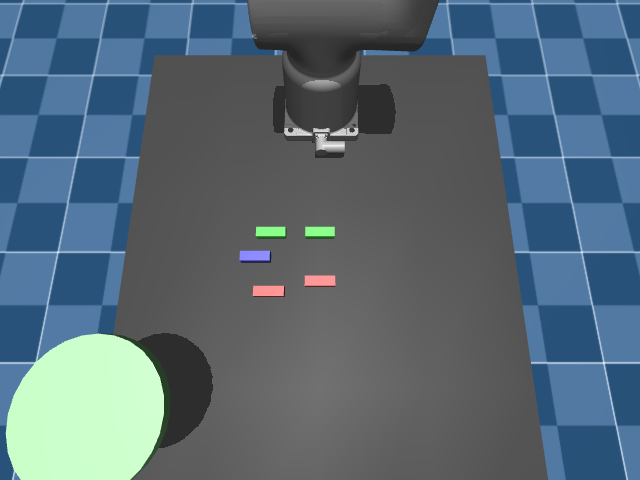

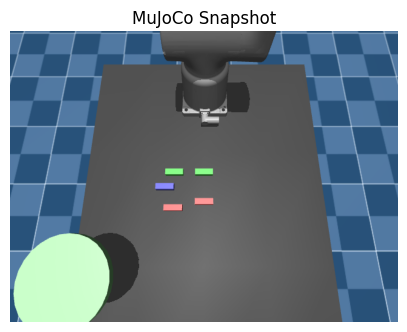

1. Robot configuration:
The robot consists of a gray cylinder connected to a larger gray cylinder. It's mounted on a flat gray surface, likely a table or workbench.

2. Objects in the scene:
- Blue and light blue checkered floor
- Gray rectangular table
- Two green rectangular blocks
- One purple rectangular block
- Two pink rectangular blocks
- Large green circular object

3. Possible pick-and-place action:
The robotic arm could be programmed to pick up one of the colored rectangular blocks and place it in a designated area on the table, such as the center or one of the corners.

4. Pixel coordinates of the green rectangular block:
Top green block: (457 483)
Bottom green block: (504 482)

5. Pixel coordinates of the large green circle:
(049 923)


In [ ]:
import imageio

# ==========================================
# Render offscreen image
# ==========================================

with mujoco.Renderer(model, 480, 640) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data, camera="external_camera")
  pixels = renderer.render()
  media.show_image(pixels)

image_path = "mujoco_snapshot.png"
imageio.imwrite(image_path, pixels)

# Display the captured image
plt.figure(figsize=(5,5))
plt.imshow(pixels)
plt.axis("off")
plt.title("MuJoCo Snapshot")
plt.show()

# ==========================================
# Send MuJoCo image to Vision-Language Model
# ==========================================

prompt = """
You are controlling a robotic arm.
Based on this image, describe:
1. The robot configuration
2. The objects in the scene
3. A possible pick-and-place action
4. point to the pixel coordinates of the green rectangular block
5. Point to the large green circle in pixel coordinates
"""

encoded_image = encode_image("mujoco_snapshot.png")

completion = client.chat.completions.create(
    model="allenai/Molmo2-8B",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": f"{prompt}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{encoded_image}"
                    }
                }
            ]
        }
    ],
)

print(completion.choices[0].message.content)
